# 🤖 Model Performance Evaluation
## Pipeline RAG — FSSM / UCA Marrakech

Ce notebook évalue les **performances complètes** du pipeline RAG : modèle d'embedding, système de retrieval FAISS, et modèle LLM.

---
**Objectifs :**
- Évaluer la qualité des embeddings (similarité, séparation inter-catégorie)
- Mesurer les performances du retrieval (Hit@K, MRR, MAP, NDCG)
- Benchmarker la vitesse d'inférence (embedding + retrieval + LLM)
- Évaluer la qualité des réponses LLM (ROUGE, cohérence sémantique)
- Comparer plusieurs configurations du pipeline

## 📦 1. Imports & Configuration

In [1]:
import os
import sys
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# ── Ajouter le répertoire racine au path ───────────────────────
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

# ── Style global ───────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Chemins ───────────────────────────────────────────────────
DATASET_ROOT  = ROOT / 'dataset'
EMBEDDINGS_DIR = ROOT / 'embeddings'
MODELS_DIR    = ROOT / 'models'

# ── Seed reproductibilité ──────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('✅ Imports OK')
print(f'📁 ROOT         : {ROOT}')
print(f'📁 Dataset      : {DATASET_ROOT}')
print(f'📁 Embeddings   : {EMBEDDINGS_DIR}')

✅ Imports OK
📁 ROOT         : C:\Users\HP\Desktop\S2\7 - Deep Learning\3 - Projet\Projet_DL_N\Projet_DL
📁 Dataset      : C:\Users\HP\Desktop\S2\7 - Deep Learning\3 - Projet\Projet_DL_N\Projet_DL\dataset
📁 Embeddings   : C:\Users\HP\Desktop\S2\7 - Deep Learning\3 - Projet\Projet_DL_N\Projet_DL\embeddings


## 📂 2. Chargement du dataset et des embeddings

In [2]:
# ── Chargement du dataset complet ─────────────────────────────
all_objects = []

for json_file in sorted(DATASET_ROOT.rglob('*.json')):

    # Ignorer le dataset final pour éviter les doublons
    if json_file.name == "final_dataset.json":
        continue

    with open(json_file, 'r', encoding='utf-8') as f:
        objects = json.load(f)

    for obj in objects:
        obj['_file'] = str(json_file.relative_to(DATASET_ROOT))

    all_objects.extend(objects)

print(f'✅ Dataset chargé : {len(all_objects)} objets')


# ── Chargement des embeddings et métadonnées ──────────────────
embeddings = np.load(EMBEDDINGS_DIR / 'embeddings.npy')

with open(EMBEDDINGS_DIR / 'metadata.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)

print(f'✅ Embeddings chargés : {embeddings.shape}  (n_docs × dim)')
print(f'✅ Métadonnées       : {len(metadata)} entrées')
print(f'\n📊 Dimension des vecteurs : {embeddings.shape[1]}')
print(f'📊 Norme moy. des vecteurs : {np.linalg.norm(embeddings, axis=1).mean():.4f}')

✅ Dataset chargé : 300 objets
✅ Embeddings chargés : (300, 768)  (n_docs × dim)
✅ Métadonnées       : 300 entrées

📊 Dimension des vecteurs : 768
📊 Norme moy. des vecteurs : 2.5292


In [6]:
# ── Installation des dépendances manquantes ───────────────────
import subprocess, sys

packages = [
    "chromadb",
    "sentence-transformers",
    "faiss-cpu",
    "rouge-score",
    "scikit-learn",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ Toutes les dépendances sont installées")

✅ Toutes les dépendances sont installées


In [10]:
import subprocess, sys

# Installe TOUT dans l'environnement exact du kernel actif
packages = ["groq", "chromadb", "sentence-transformers", 
            "faiss-cpu", "rouge-score", "scikit-learn"]

for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    status = "✅" if result.returncode == 0 else "❌"
    print(f"  {status} {pkg}")

print(f"\n📍 Python utilisé : {sys.executable}")

  ✅ groq
  ✅ chromadb
  ✅ sentence-transformers
  ✅ faiss-cpu
  ✅ rouge-score
  ✅ scikit-learn

📍 Python utilisé : c:\Users\HP\anaconda3\python.exe


In [11]:
print(f"📍 Python path : {sys.executable}\n")

checks = {
    "groq"                : "groq",
    "chromadb"            : "chromadb", 
    "sentence_transformers": "sentence_transformers",
    "faiss"               : "faiss",
    "rouge_score"         : "rouge_score",
    "sklearn"             : "sklearn",
}

all_ok = True
for name, mod in checks.items():
    try:
        __import__(mod)
        print(f"  ✅ {name}")
    except ImportError:
        print(f"  ❌ {name} — non trouvé")
        all_ok = False

print("\n✅ Tout est prêt !" if all_ok else "\n❌ Relancer la cellule d'installation")

📍 Python path : c:\Users\HP\anaconda3\python.exe

  ✅ groq
  ✅ chromadb
  ✅ sentence_transformers
  ✅ faiss
  ✅ rouge_score
  ✅ sklearn

✅ Tout est prêt !


In [14]:
import sys, inspect
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# ── Retrieval ──────────────────────────────────────────────────
from models.retrieval    import get_retriever, EmbeddingModel

# ── RAG Pipeline ──────────────────────────────────────────────
from models.rag_pipeline import get_rag_pipeline

# ── LLM : détecter la bonne fonction automatiquement ──────────
import models.llm as llm_module

print("📋 Fonctions dans llm.py :")
llm_functions = [
    name for name, obj in inspect.getmembers(llm_module)
    if not name.startswith("_") and callable(obj)
]
for f in llm_functions:
    print(f"  → {f}")

# Chercher une fonction de génération
POSSIBLE = ["generate_answer", "generate", "ask", "chat", 
            "complete", "get_response", "answer", "query"]

generate_answer = None
for name in POSSIBLE:
    if hasattr(llm_module, name):
        generate_answer = getattr(llm_module, name)
        print(f"\n✅ Fonction LLM trouvée : '{name}'")
        break

if generate_answer is None:
    print("\n⚠️  Aucune fonction standard trouvée.")
    print("    Utilisation du LLMClient directement via get_llm_client()")
    from models.llm import get_llm_client
    llm_client = get_llm_client()
    # Wrapper manuel
    def generate_answer(question, context):
        return llm_client.answer(question, context)

📋 Fonctions dans llm.py :
  → Groq
  → LLMClient
  → get_llm_client

⚠️  Aucune fonction standard trouvée.
    Utilisation du LLMClient directement via get_llm_client()


In [15]:
import sys, inspect
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# ── Imports corrects ───────────────────────────────────────────
from models.retrieval    import get_retriever, EmbeddingModel
from models.rag_pipeline import get_rag_pipeline
from models.llm          import get_llm_client, LLMClient

# ── Initialisation ─────────────────────────────────────────────
print("🔄 Chargement du modèle d'embedding...")
t0 = time.time()
embed_model = EmbeddingModel()
_ = embed_model.encode(["test"])          # warm-up
print(f"✅ Embedding model chargé en {time.time()-t0:.2f}s")

print("\n🔄 Chargement du Retriever ChromaDB...")
t0 = time.time()
retriever = get_retriever()
n_docs = retriever.collection.count()
print(f"✅ Retriever prêt en {time.time()-t0:.2f}s — {n_docs} documents indexés")

print("\n🔄 Chargement du LLM client...")
t0 = time.time()
llm_client = get_llm_client()
print(f"✅ LLM client prêt en {time.time()-t0:.2f}s")

print("\n🔄 Chargement du pipeline RAG complet...")
t0 = time.time()
rag = get_rag_pipeline()
print(f"✅ Pipeline RAG prêt en {time.time()-t0:.2f}s")

# ── Wrapper generate_answer pour le reste du notebook ─────────
def generate_answer(question: str, context: str) -> str:
    """Wrapper unifié pour appeler le LLMClient."""
    try:
        # Essaye les méthodes possibles du LLMClient
        for method in ["answer", "generate", "ask", "chat", "complete", "query"]:
            if hasattr(llm_client, method):
                result = getattr(llm_client, method)(question, context)
                return result if isinstance(result, str) else str(result)
    except Exception as e:
        return f"[Erreur LLM] {e}"
    return "[Méthode LLM non trouvée]"

print("\n✅ generate_answer() wrapper prêt")
print(f"\n📋 Méthodes disponibles dans LLMClient :")
for name in inspect.getmembers(llm_client):
    if not name[0].startswith("_") and callable(name[1]):
        print(f"   → {name[0]}")

🔄 Chargement du modèle d'embedding...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Embedding model chargé en 13.83s

🔄 Chargement du Retriever ChromaDB...
✅ Retriever prêt en 0.69s — 300 documents indexés

🔄 Chargement du LLM client...
✅ LLM client prêt en 0.00s

🔄 Chargement du pipeline RAG complet...
✅ Pipeline RAG prêt en 0.00s

✅ generate_answer() wrapper prêt

📋 Méthodes disponibles dans LLMClient :
   → generate
   → generate_stream


## 🧲 3. Évaluation du modèle d'embedding

In [16]:
# ── Statistiques de base sur les embeddings ───────────────────
norms = np.linalg.norm(embeddings, axis=1)

print('📐 Statistiques des vecteurs d\'embedding :\n')
print(f'  Dimension               : {embeddings.shape[1]}')
print(f'  Nb vecteurs             : {embeddings.shape[0]}')
print(f'  Norme moyenne           : {norms.mean():.4f}')
print(f'  Norme std               : {norms.std():.4f}')
print(f'  Norme min / max         : {norms.min():.4f} / {norms.max():.4f}')
print(f'  Valeur moy. globale     : {embeddings.mean():.6f}')
print(f'  Valeur std  globale     : {embeddings.std():.6f}')

# Vecteurs normalisés L2
emb_norm = embeddings / (norms[:, np.newaxis] + 1e-9)
print(f'\n  Vecteurs normalisés L2  : OK (norme ≈ {np.linalg.norm(emb_norm, axis=1).mean():.4f})')

📐 Statistiques des vecteurs d'embedding :

  Dimension               : 768
  Nb vecteurs             : 300
  Norme moyenne           : 2.5292
  Norme std               : 0.1663
  Norme min / max         : 1.5869 / 2.8568
  Valeur moy. globale     : 0.001822
  Valeur std  globale     : 0.091443

  Vecteurs normalisés L2  : OK (norme ≈ 1.0000)


In [17]:
# ── Vitesse d'encodage ────────────────────────────────────────
test_sentences = [
    "Quels documents pour s'inscrire à la FSSM ?",
    "Comment obtenir un relevé de notes ?",
    "Date des examens de rattrapage ?",
    "Master informatique FSSM conditions ?",
    "Règles d'absences FSSM ?",
]

# Warm-up
_ = embed_model.encode([test_sentences[0]])

# Benchmark single query
times_single = []
for _ in range(30):
    t0 = time.perf_counter()
    embed_model.encode([test_sentences[0]])
    times_single.append((time.perf_counter() - t0) * 1000)

# Benchmark batch
times_batch = []
for _ in range(20):
    t0 = time.perf_counter()
    embed_model.encode(test_sentences)
    times_batch.append((time.perf_counter() - t0) * 1000)

print('⚡ Vitesse d\'encodage :\n')
print(f'  Single query  — moy: {np.mean(times_single):.2f} ms  | std: {np.std(times_single):.2f} ms')
print(f'  Batch (x5)    — moy: {np.mean(times_batch):.2f} ms  | std: {np.std(times_batch):.2f} ms')
print(f'  Débit         — {1000/np.mean(times_single):.0f} requêtes/sec (single)')

⚡ Vitesse d'encodage :

  Single query  — moy: 88.25 ms  | std: 13.14 ms
  Batch (x5)    — moy: 214.58 ms  | std: 24.37 ms
  Débit         — 11 requêtes/sec (single)


In [18]:
# ── Similarité intra / inter catégorie ───────────────────────
from sklearn.metrics.pairwise import cosine_similarity

cat_map = defaultdict(list)
for i, obj in enumerate(all_objects):
    if i < len(embeddings):
        cat_map[obj.get('category', 'N/A')].append(i)

intra_sims, inter_sims = [], []
categories = list(cat_map.keys())

for cat in categories:
    idxs = cat_map[cat]
    if len(idxs) < 2:
        continue
    sample = random.sample(idxs, min(15, len(idxs)))
    vecs = emb_norm[sample]
    sim_mat = cosine_similarity(vecs)
    np.fill_diagonal(sim_mat, np.nan)
    intra_sims.extend(sim_mat[~np.isnan(sim_mat)].tolist())

for i in range(len(categories)):
    for j in range(i+1, len(categories)):
        si = random.sample(cat_map[categories[i]], min(8, len(cat_map[categories[i]])))
        sj = random.sample(cat_map[categories[j]], min(8, len(cat_map[categories[j]])))
        sim = cosine_similarity(emb_norm[si], emb_norm[sj])
        inter_sims.extend(sim.flatten().tolist())

print('🔬 Similarité cosinus intra / inter catégorie :\n')
print(f'  Intra-catégorie  moy : {np.mean(intra_sims):.4f}  | std : {np.std(intra_sims):.4f}')
print(f'  Inter-catégorie  moy : {np.mean(inter_sims):.4f}  | std : {np.std(inter_sims):.4f}')
sep = np.mean(intra_sims) - np.mean(inter_sims)
print(f'\n  ✅ Séparation (intra − inter) : {sep:.4f}')
print(f'  → {"Bonne" if sep > 0.05 else "Faible"} séparation sémantique inter-catégorie')

🔬 Similarité cosinus intra / inter catégorie :

  Intra-catégorie  moy : 0.5723  | std : 0.0991
  Inter-catégorie  moy : 0.4873  | std : 0.1165

  ✅ Séparation (intra − inter) : 0.0849
  → Bonne séparation sémantique inter-catégorie


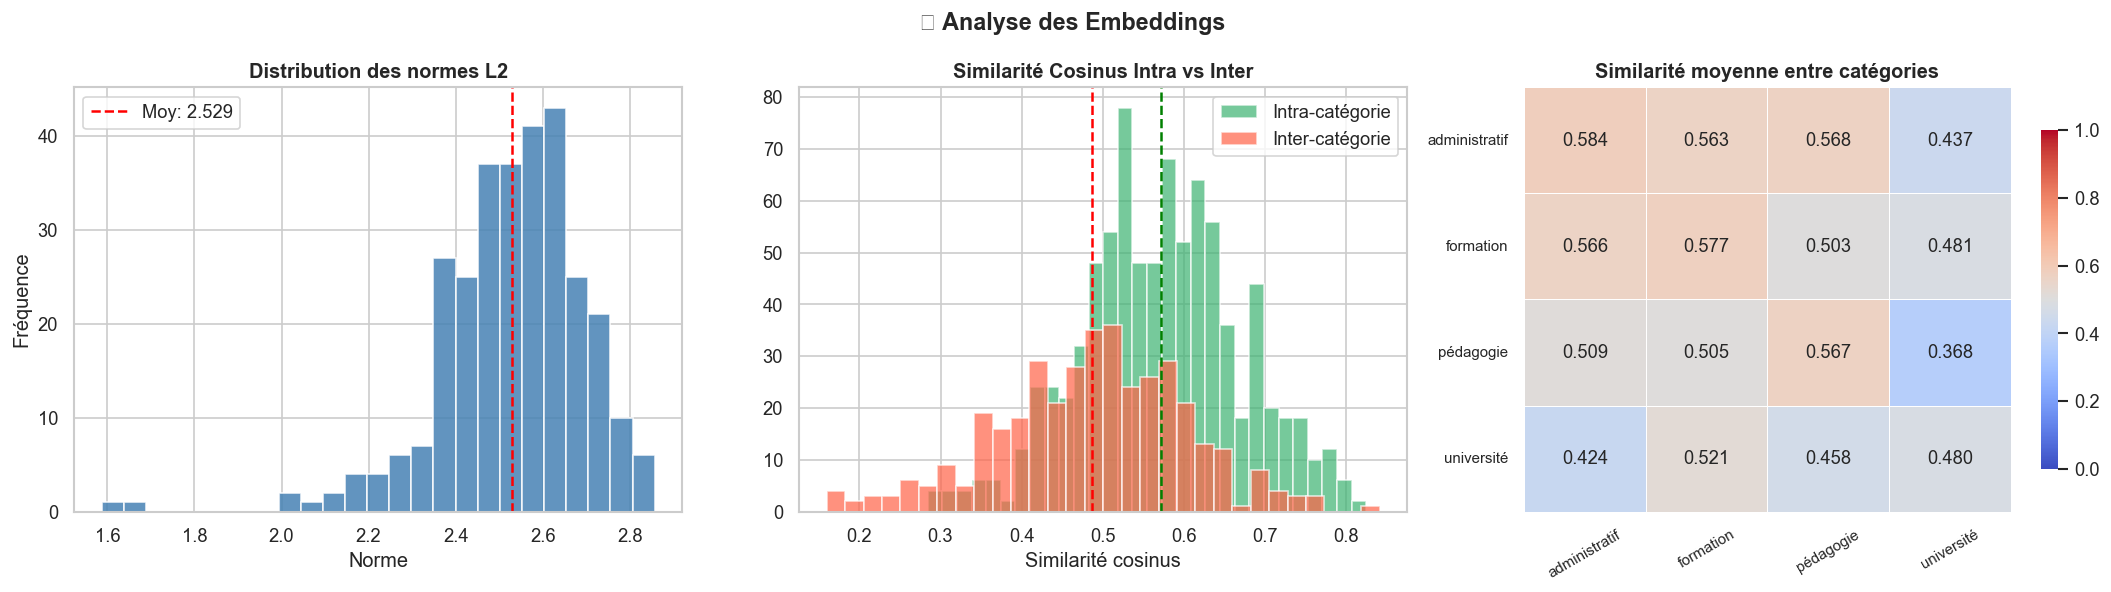

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🧲 Analyse des Embeddings', fontsize=14, fontweight='bold')

# 1) Distribution des normes
ax = axes[0]
ax.hist(norms, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(norms.mean(), color='red', linestyle='--', label=f'Moy: {norms.mean():.3f}')
ax.set_title('Distribution des normes L2', fontweight='bold')
ax.set_xlabel('Norme')
ax.set_ylabel('Fréquence')
ax.legend()

# 2) Similarité intra vs inter
ax = axes[1]
ax.hist(intra_sims, bins=30, alpha=0.7, color='mediumseagreen', label='Intra-catégorie', edgecolor='white')
ax.hist(inter_sims, bins=30, alpha=0.7, color='tomato',         label='Inter-catégorie', edgecolor='white')
ax.axvline(np.mean(intra_sims), color='green', linestyle='--', linewidth=1.5)
ax.axvline(np.mean(inter_sims), color='red',   linestyle='--', linewidth=1.5)
ax.set_title('Similarité Cosinus Intra vs Inter', fontweight='bold')
ax.set_xlabel('Similarité cosinus')
ax.legend()

# 3) Heatmap similarité catégorie × catégorie
ax = axes[2]
cat_sim_matrix = np.zeros((len(categories), len(categories)))
for i, ci in enumerate(categories):
    for j, cj in enumerate(categories):
        si = random.sample(cat_map[ci], min(10, len(cat_map[ci])))
        sj = random.sample(cat_map[cj], min(10, len(cat_map[cj])))
        cat_sim_matrix[i, j] = cosine_similarity(emb_norm[si], emb_norm[sj]).mean()

sns.heatmap(cat_sim_matrix, xticklabels=categories, yticklabels=categories,
            annot=True, fmt='.3f', cmap='coolwarm', ax=ax,
            vmin=0, vmax=1, linewidths=0.5, cbar_kws={'shrink':0.8})
ax.set_title('Similarité moyenne entre catégories', fontweight='bold')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('embeddings_analysis.png', bbox_inches='tight')
plt.show()

## 🗺️ 4. Visualisation 2D des embeddings (PCA + t-SNE)

In [21]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sklearn

labels = [obj.get('category', 'N/A') for obj in all_objects[:len(embeddings)]]
unique_cats = list(set(labels))
color_map = {cat: plt.cm.Set1(i/len(unique_cats)) for i, cat in enumerate(unique_cats)}
colors_pts = [color_map[l] for l in labels]

# ── PCA (rapide) ──────────────────────────────────────────────
print('🔄 PCA en cours...')
t0 = time.time()
pca = PCA(n_components=2, random_state=SEED)
emb_pca = pca.fit_transform(embeddings)
print(f'✅ PCA terminée en {time.time()-t0:.2f}s')
print(f'   Variance expliquée : PC1={pca.explained_variance_ratio_[0]*100:.1f}%  PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

# ── t-SNE (plus précis) ───────────────────────────────────────
print(f'\n🔄 t-SNE en cours (peut prendre ~30s)...')
print(f'   scikit-learn version : {sklearn.__version__}')
t0 = time.time()

sk_version = tuple(int(x) for x in sklearn.__version__.split(".")[:2])
iter_param = "max_iter" if sk_version >= (1, 2) else "n_iter"

tsne = TSNE(
    n_components=2,
    perplexity=30,
    **{iter_param: 1000},
    random_state=SEED,
    verbose=0
)
emb_tsne = tsne.fit_transform(embeddings)
print(f'✅ t-SNE terminée en {time.time()-t0:.2f}s')

🔄 PCA en cours...
✅ PCA terminée en 0.05s
   Variance expliquée : PC1=12.7%  PC2=8.2%

🔄 t-SNE en cours (peut prendre ~30s)...
   scikit-learn version : 1.7.2
✅ t-SNE terminée en 6.58s


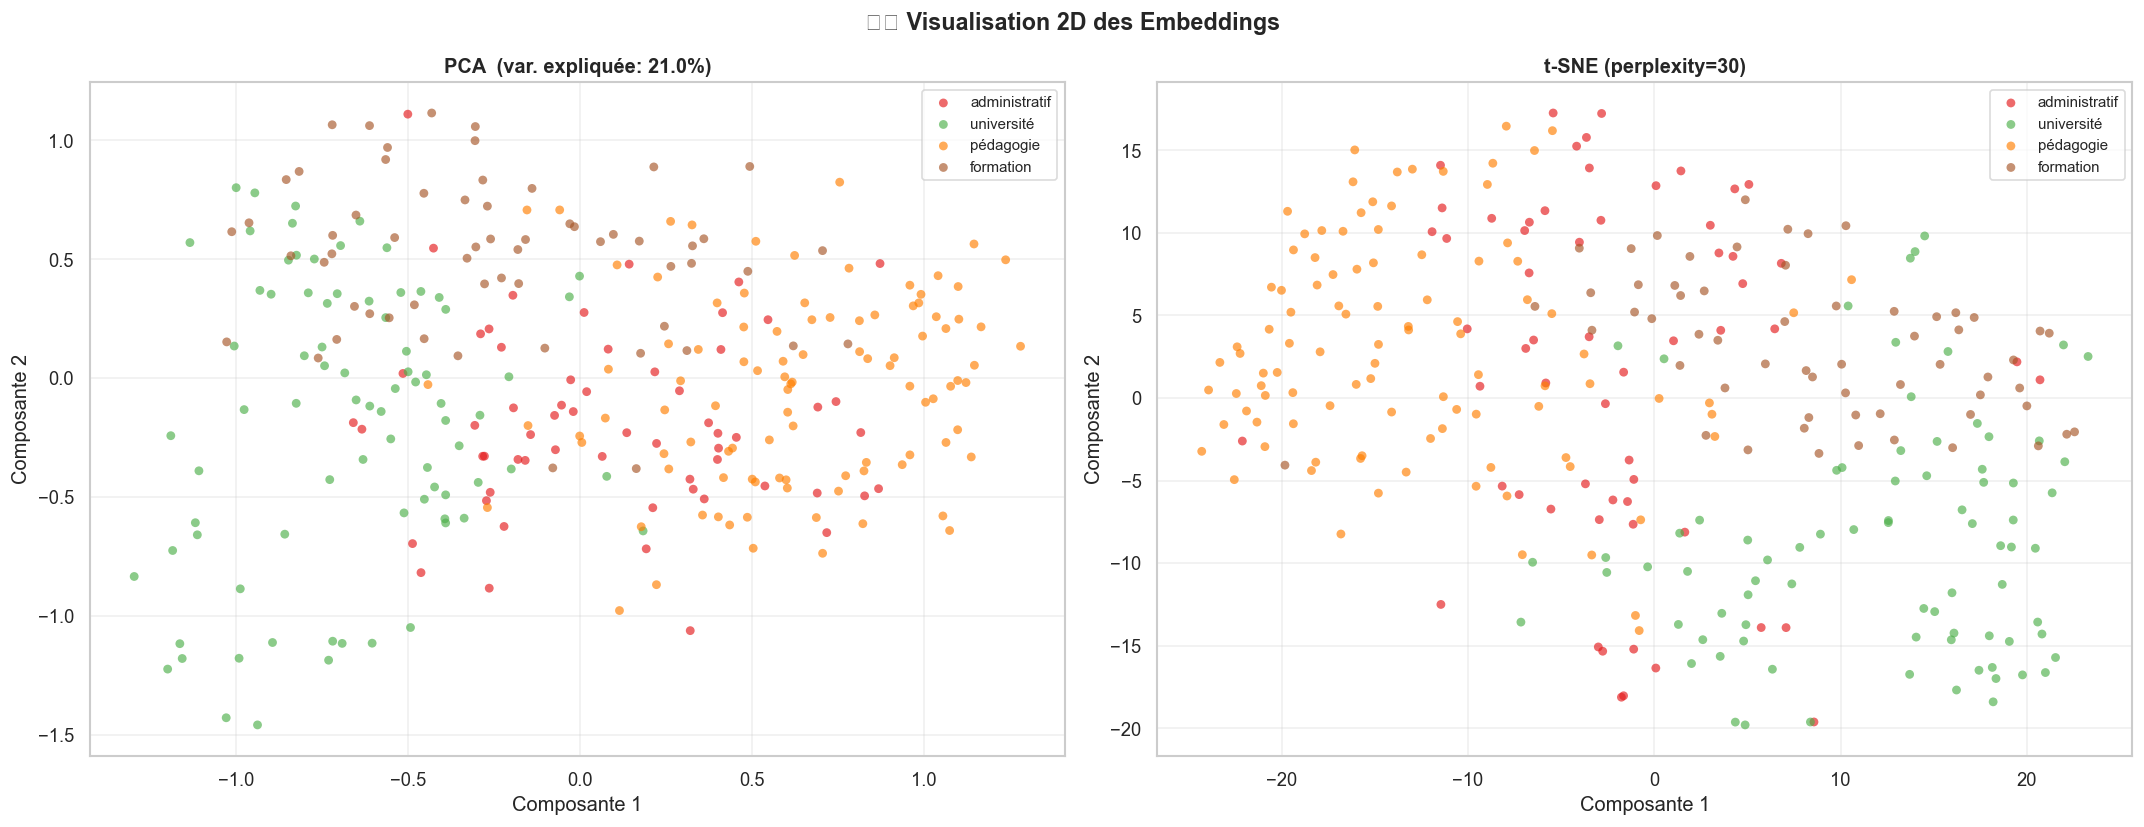

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🗺️ Visualisation 2D des Embeddings', fontsize=14, fontweight='bold')

for ax, (proj, title) in zip(axes, [
    (emb_pca,  f'PCA  (var. expliquée: {sum(pca.explained_variance_ratio_)*100:.1f}%)'),
    (emb_tsne, 't-SNE (perplexity=30)')
]):
    for cat in unique_cats:
        mask = [l == cat for l in labels]
        pts  = proj[mask]
        ax.scatter(pts[:, 0], pts[:, 1], c=[color_map[cat]],
                   label=cat, alpha=0.65, s=28, edgecolors='none')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9, loc='best', framealpha=0.7)
    ax.set_xlabel('Composante 1')
    ax.set_ylabel('Composante 2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('embeddings_2d.png', bbox_inches='tight')
plt.show()

## 🔍 5. Évaluation du Retrieval FAISS (Hit@K · MRR · MAP · NDCG)

In [23]:
# ── Construction du jeu de test ───────────────────────────────
# Pour chaque objet du dataset, on prend UNE question de test
# et on s'attend à retrouver le bon contexte (même id) en top-K

test_queries = []
for i, obj in enumerate(all_objects):
    if i >= len(embeddings):
        break
    questions = obj.get('questions', [])
    if not questions:
        continue
    # Prendre une question NOT vue pendant l'indexation si possible
    q = random.choice(questions)
    test_queries.append({
        'query'       : q,
        'relevant_idx': i,           # index dans la base d'embeddings
        'relevant_id' : obj.get('id'),
        'category'    : obj.get('category'),
    })

# Limiter à 200 requêtes pour la vitesse
test_queries = random.sample(test_queries, min(200, len(test_queries)))
print(f'✅ Jeu de test : {len(test_queries)} requêtes')

✅ Jeu de test : 200 requêtes


In [24]:
def compute_retrieval_metrics(test_queries, embed_model, embeddings, top_k_list=[1, 3, 5, 10]):
    """Calcule Hit@K, MRR, MAP, NDCG pour le retrieval."""
    emb_norm_base = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9)

    hits       = {k: 0 for k in top_k_list}
    mrr_scores = []
    ndcg_scores= []
    latencies  = []
    per_query  = []

    for item in test_queries:
        t0 = time.perf_counter()
        q_vec = embed_model.encode([item['query']])
        q_vec_n = q_vec / (np.linalg.norm(q_vec) + 1e-9)
        sims = (emb_norm_base @ q_vec_n.T).squeeze()
        ranked = np.argsort(sims)[::-1]
        latency_ms = (time.perf_counter() - t0) * 1000
        latencies.append(latency_ms)

        rel_idx = item['relevant_idx']
        rank = np.where(ranked == rel_idx)[0]
        rank_pos = int(rank[0]) + 1 if len(rank) > 0 else 9999

        # Hit@K
        for k in top_k_list:
            if rank_pos <= k:
                hits[k] += 1

        # MRR
        mrr_scores.append(1.0 / rank_pos if rank_pos <= max(top_k_list) else 0.0)

        # NDCG@10
        k_ndcg = 10
        top_k_idxs = ranked[:k_ndcg]
        relevance = [1 if idx == rel_idx else 0 for idx in top_k_idxs]
        dcg  = sum(r / np.log2(i+2) for i, r in enumerate(relevance))
        idcg = 1.0  # ideal: doc at rank 1
        ndcg_scores.append(dcg / idcg)

        per_query.append({
            'query'   : item['query'][:60],
            'category': item['category'],
            'rank'    : rank_pos,
            'mrr'     : round(1.0 / rank_pos if rank_pos <= max(top_k_list) else 0, 4),
            'ndcg@10' : round(dcg / idcg, 4),
            'latency_ms': round(latency_ms, 2),
        })

    n = len(test_queries)
    results = {
        **{f'Hit@{k}': hits[k]/n for k in top_k_list},
        'MRR'      : np.mean(mrr_scores),
        'NDCG@10'  : np.mean(ndcg_scores),
        'Latence moy (ms)': np.mean(latencies),
        'Latence p95 (ms)': np.percentile(latencies, 95),
    }
    return results, pd.DataFrame(per_query), latencies

print('🔄 Évaluation du retrieval en cours...')
t0 = time.time()
metrics, df_per_query, latencies = compute_retrieval_metrics(
    test_queries, embed_model, embeddings
)
print(f'✅ Évaluation terminée en {time.time()-t0:.2f}s\n')

print('='*50)
print('       📊 MÉTRIQUES DE RETRIEVAL')
print('='*50)
for k, v in metrics.items():
    if 'Hit' in k or 'MRR' in k or 'NDCG' in k:
        bar = '█' * int(v * 20)
        print(f'  {k:18s} : {v:.4f}  |{bar}')
    else:
        print(f'  {k:18s} : {v:.2f}')
print('='*50)

🔄 Évaluation du retrieval en cours...
✅ Évaluation terminée en 16.53s

       📊 MÉTRIQUES DE RETRIEVAL
  Hit@1              : 0.3950  |███████
  Hit@3              : 0.6450  |████████████
  Hit@5              : 0.6900  |█████████████
  Hit@10             : 0.7700  |███████████████
  MRR                : 0.5248  |██████████
  NDCG@10            : 0.5843  |███████████
  Latence moy (ms)   : 82.43
  Latence p95 (ms)   : 108.31


In [25]:
# ── Performance par catégorie ─────────────────────────────────
print('\n📊 Performance par catégorie :\n')
cat_perf = df_per_query.groupby('category').agg(
    nb_requetes=('query','count'),
    rank_moyen =('rank', 'mean'),
    MRR        =('mrr',  'mean'),
    NDCG_10    =('ndcg@10','mean'),
    latence_moy=('latency_ms','mean')
).round(4)

# Hit@1 et Hit@5 par catégorie
for cat, grp in df_per_query.groupby('category'):
    cat_perf.loc[cat, 'Hit@1'] = (grp['rank'] == 1).mean().round(4)
    cat_perf.loc[cat, 'Hit@5'] = (grp['rank'] <= 5).mean().round(4)

display(cat_perf.sort_values('MRR', ascending=False))


📊 Performance par catégorie :



,nb_requetes,rank_moyen,MRR,NDCG_10,latence_moy,Hit@1,Hit@5
category,,,,,,,
formation,38,10.5000,0.5776,0.6305,83.1666,0.4474,0.7632
administratif,40,11.8750,0.5472,0.6009,79.6575,0.4500,0.6750
université,56,11.2143,0.5166,0.5722,79.6496,0.4107,0.6429
pédagogie,66,10.4394,0.4877,0.5580,86.0415,0.3182,0.6970


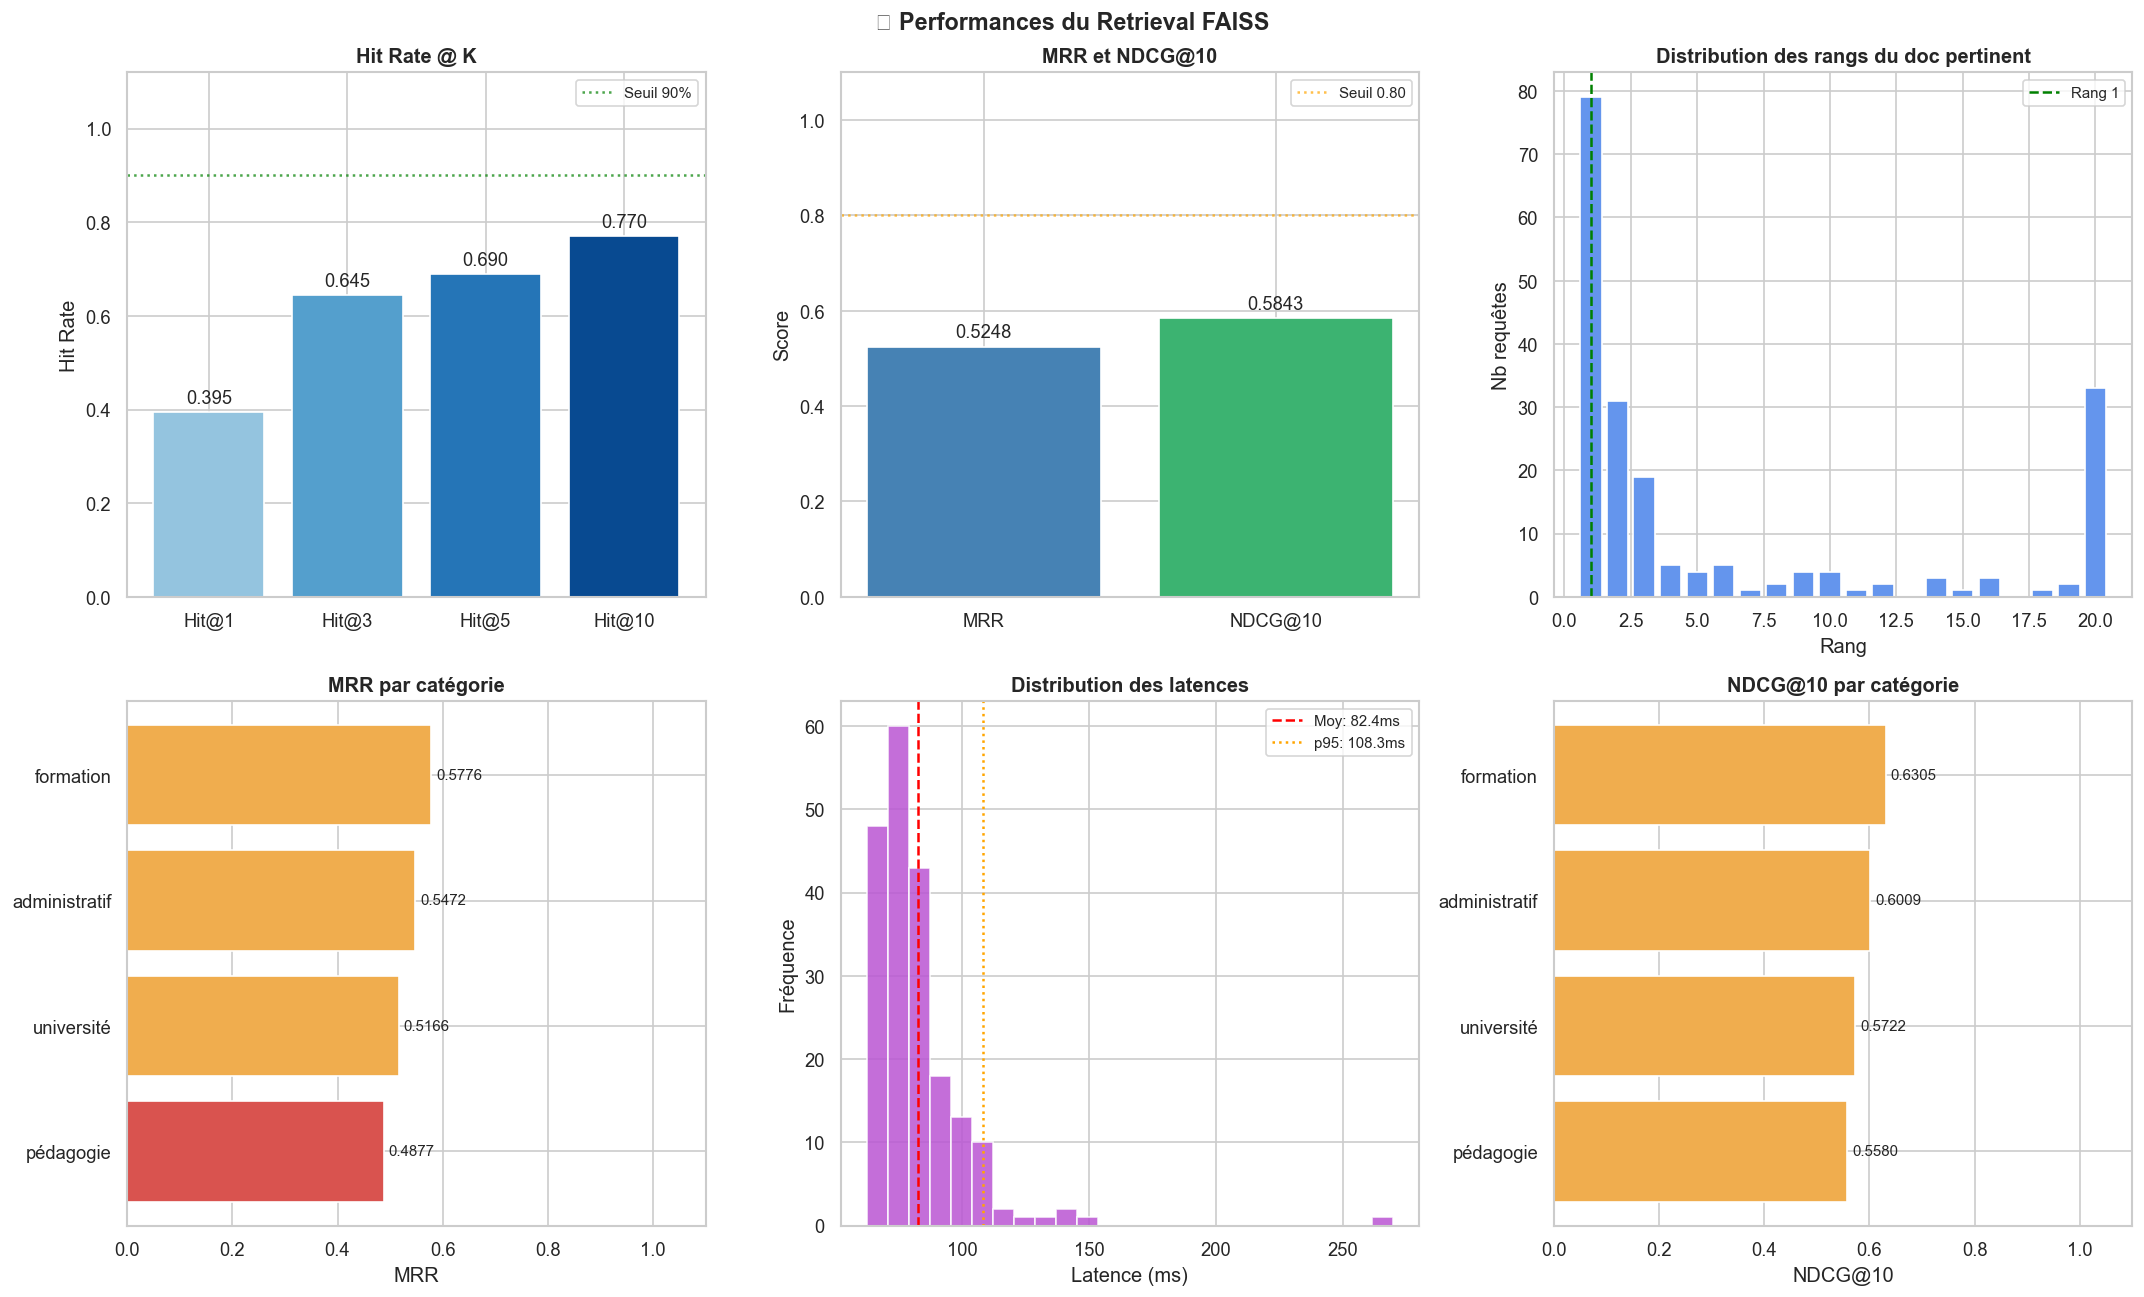

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('🔍 Performances du Retrieval FAISS', fontsize=14, fontweight='bold')

K_VALUES = [1, 3, 5, 10]

# 1) Hit@K
ax = axes[0, 0]
hit_vals = [metrics[f'Hit@{k}'] for k in K_VALUES]
bars = ax.bar([f'Hit@{k}' for k in K_VALUES], hit_vals,
              color=plt.cm.Blues(np.linspace(0.4, 0.9, len(K_VALUES))), edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylim(0, 1.12)
ax.set_title('Hit Rate @ K', fontweight='bold')
ax.set_ylabel('Hit Rate')
ax.axhline(0.9, color='green', linestyle=':', alpha=0.7, label='Seuil 90%')
ax.legend(fontsize=9)

# 2) MRR et NDCG
ax = axes[0, 1]
metric_names = ['MRR', 'NDCG@10']
metric_vals  = [metrics['MRR'], metrics['NDCG@10']]
bars = ax.bar(metric_names, metric_vals, color=['steelblue','mediumseagreen'], edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0, 1.1)
ax.set_title('MRR et NDCG@10', fontweight='bold')
ax.set_ylabel('Score')
ax.axhline(0.8, color='orange', linestyle=':', alpha=0.7, label='Seuil 0.80')
ax.legend(fontsize=9)

# 3) Distribution des rangs
ax = axes[0, 2]
ranks = df_per_query['rank'].clip(upper=20)
rank_cnt = ranks.value_counts().sort_index()
ax.bar(rank_cnt.index, rank_cnt.values, color='cornflowerblue', edgecolor='white')
ax.set_title('Distribution des rangs du doc pertinent', fontweight='bold')
ax.set_xlabel('Rang')
ax.set_ylabel('Nb requêtes')
ax.axvline(1, color='green', linestyle='--', label='Rang 1')
ax.legend(fontsize=9)

# 4) MRR par catégorie
ax = axes[1, 0]
cat_mrr = cat_perf['MRR'].sort_values()
colors_bar = ['#d9534f' if v < 0.5 else '#f0ad4e' if v < 0.75 else '#5cb85c' for v in cat_mrr]
bars = ax.barh(cat_mrr.index, cat_mrr.values, color=colors_bar, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_title('MRR par catégorie', fontweight='bold')
ax.set_xlabel('MRR')
ax.set_xlim(0, 1.1)

# 5) Latence distribution
ax = axes[1, 1]
ax.hist(latencies, bins=25, color='mediumorchid', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(latencies),       color='red',    linestyle='--', label=f'Moy: {np.mean(latencies):.1f}ms')
ax.axvline(np.percentile(latencies,95),color='orange',linestyle=':',  label=f'p95: {np.percentile(latencies,95):.1f}ms')
ax.set_title('Distribution des latences', fontweight='bold')
ax.set_xlabel('Latence (ms)')
ax.set_ylabel('Fréquence')
ax.legend(fontsize=9)

# 6) NDCG@10 par catégorie
ax = axes[1, 2]
cat_ndcg = cat_perf['NDCG_10'].sort_values()
colors_bar = ['#d9534f' if v < 0.5 else '#f0ad4e' if v < 0.75 else '#5cb85c' for v in cat_ndcg]
bars = ax.barh(cat_ndcg.index, cat_ndcg.values, color=colors_bar, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_title('NDCG@10 par catégorie', fontweight='bold')
ax.set_xlabel('NDCG@10')
ax.set_xlim(0, 1.1)

plt.tight_layout()
plt.savefig('retrieval_metrics.png', bbox_inches='tight')
plt.show()

## 🤖 6. Évaluation des réponses LLM (ROUGE + cohérence sémantique)

In [27]:
# ── Jeu de test pour le LLM ───────────────────────────────────
llm_test_set = [
    {"question": "Quels documents sont nécessaires pour s'inscrire à la FSSM ?",
     "reference": "Copie du bac, CIN, photos d'identité et formulaire d'inscription."},
    {"question": "Comment obtenir une attestation d'inscription à la FSSM ?",
     "reference": "Elle est délivrée par le service de scolarité sur présentation de la carte étudiant."},
    {"question": "Quelle est la durée d'une licence à la FSSM ?",
     "reference": "La licence dure 3 ans soit 6 semestres selon le système LMD."},
    {"question": "Comment s'inscrire en master à la FSSM ?",
     "reference": "Via la plateforme e-candidature.uca.ma avec CV, relevés de notes et lettre de motivation."},
    {"question": "Combien d'absences sont tolérées à la FSSM ?",
     "reference": "Le taux d'absence toléré est de 25% par module."},
    {"question": "Qu'est-ce que le CeDoc de la FSSM ?",
     "reference": "Le Centre Doctoral qui gère les inscriptions et formations des doctorants."},
    {"question": "Comment valide-t-on un module à la FSSM ?",
     "reference": "En obtenant une note finale supérieure ou égale à 10/20."},
    {"question": "Quelles filières de licence existent à la FSSM ?",
     "reference": "MI, SMP, SMC, SVT, STT et des licences professionnelles."},
    {"question": "Quand a lieu la session de rattrapage à la FSSM ?",
     "reference": "En février pour S1 et en juillet pour S2, après la session normale."},
    {"question": "La FSSM dispose-t-elle d'une bibliothèque numérique ?",
     "reference": "Oui, accessible sur biblio-fssm.uca.ma avec des revues et bases de données."},
]
print(f'✅ Jeu de test LLM : {len(llm_test_set)} questions')

✅ Jeu de test LLM : 10 questions


In [30]:
# ── Diagnostic rapide ─────────────────────────────────────────
import inspect
test_resp = rag.answer("Quels documents pour s'inscrire ?")
print(f"Type retourné : {type(test_resp)}")
print(f"Attributs disponibles : {[a for a in dir(test_resp) if not a.startswith('_')]}")
print(f"\nContenu :")
for attr in [a for a in dir(test_resp) if not a.startswith('_')]:
    try:
        print(f"  .{attr} = {str(getattr(test_resp, attr))[:80]}")
    except:
        pass

Type retourné : <class 'models.rag_pipeline.RAGResponse'>
Attributs disponibles : ['answer', 'query', 'sources', 'top_k']

Contenu :
  .answer = Pour s'inscrire, les documents requis sont :

- Une copie du baccalauréat
- La c
  .query = Quels documents pour s'inscrire ?
  .sources = [{'metadata': "{'category': 'administratif', 'tags': ['documents', 'inscription'
  .top_k = 5


In [31]:
# ── Génération des réponses corrigée ──────────────────────────
print('🔄 Génération des réponses LLM...\n')

def extract_field(response, *field_names, default=''):
    """Extrait un champ depuis un dict OU un objet RAGResponse."""
    for field in field_names:
        # Si c'est un dict
        if isinstance(response, dict) and field in response:
            return response[field]
        # Si c'est un objet dataclass/objet
        if hasattr(response, field):
            val = getattr(response, field)
            if val is not None:
                return val
    return default

llm_results = []
for i, item in enumerate(llm_test_set):
    t0 = time.perf_counter()
    response = rag.answer(item['question'])
    latency  = (time.perf_counter() - t0) * 1000

    # Extraction compatible dict ET RAGResponse
    generated    = extract_field(response, 'answer', 'text', 'response', 'content')
    context_used = extract_field(response, 'context', 'context_used', 'retrieved_context')

    llm_results.append({
        'question'    : item['question'],
        'reference'   : item['reference'],
        'generated'   : str(generated),
        'context_used': str(context_used)[:200],
        'latency_ms'  : round(latency, 1),
    })
    print(f'  [{i+1:02d}/{len(llm_test_set)}] ✅  ({latency:.0f}ms)  {item["question"][:55]}')

df_llm = pd.DataFrame(llm_results)
print(f'\n✅ Génération terminée — latence moy. : {df_llm["latency_ms"].mean():.0f} ms')
print(f'\n📋 Aperçu des réponses générées :')
display(df_llm[['question','generated','latency_ms']].head(3))

🔄 Génération des réponses LLM...

  [01/10] ✅  (776ms)  Quels documents sont nécessaires pour s'inscrire à la F
  [02/10] ✅  (844ms)  Comment obtenir une attestation d'inscription à la FSSM
  [03/10] ✅  (342ms)  Quelle est la durée d'une licence à la FSSM ?
  [04/10] ✅  (759ms)  Comment s'inscrire en master à la FSSM ?
  [05/10] ✅  (553ms)  Combien d'absences sont tolérées à la FSSM ?
  [06/10] ✅  (572ms)  Qu'est-ce que le CeDoc de la FSSM ?
  [07/10] ✅  (724ms)  Comment valide-t-on un module à la FSSM ?
  [08/10] ✅  (3753ms)  Quelles filières de licence existent à la FSSM ?
  [09/10] ✅  (509ms)  Quand a lieu la session de rattrapage à la FSSM ?
  [10/10] ✅  (3488ms)  La FSSM dispose-t-elle d'une bibliothèque numérique ?

✅ Génération terminée — latence moy. : 1232 ms

📋 Aperçu des réponses générées :


,question,generated,latency_ms
0,Quels documents sont nécessaires pour s'inscri...,"D'après le contexte fourni, les documents néce...",776.4
1,Comment obtenir une attestation d'inscription ...,Pour obtenir une attestation d'inscription à l...,843.6
2,Quelle est la durée d'une licence à la FSSM ?,"La durée d'une licence à la FSSM est de 3 ans,...",342.4


In [32]:
# ── ROUGE scores ──────────────────────────────────────────────
try:
    from rouge_score import rouge_scorer
    scorer = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=False)
    rouge_available = True
except ImportError:
    print('⚠️  rouge_score non installé → pip install rouge-score')
    rouge_available = False

if rouge_available:
    r1_list, r2_list, rl_list = [], [], []
    for _, row in df_llm.iterrows():
        scores_r = scorer.score(row['reference'], row['generated'])
        r1_list.append(scores_r['rouge1'].fmeasure)
        r2_list.append(scores_r['rouge2'].fmeasure)
        rl_list.append(scores_r['rougeL'].fmeasure)

    df_llm['ROUGE-1'] = r1_list
    df_llm['ROUGE-2'] = r2_list
    df_llm['ROUGE-L'] = rl_list

    print('📊 ROUGE Scores (réf. vs généré) :\n')
    print(f'  ROUGE-1  moy : {np.mean(r1_list):.4f}  | std : {np.std(r1_list):.4f}')
    print(f'  ROUGE-2  moy : {np.mean(r2_list):.4f}  | std : {np.std(r2_list):.4f}')
    print(f'  ROUGE-L  moy : {np.mean(rl_list):.4f}  | std : {np.std(rl_list):.4f}')

📊 ROUGE Scores (réf. vs généré) :

  ROUGE-1  moy : 0.3128  | std : 0.1452
  ROUGE-2  moy : 0.1881  | std : 0.1148
  ROUGE-L  moy : 0.2807  | std : 0.1451


In [33]:
# ── Cohérence sémantique (similarité cosinus réf. vs généré) ──
print('\n🔄 Calcul de la cohérence sémantique...')
from sklearn.metrics.pairwise import cosine_similarity

refs  = df_llm['reference'].tolist()
gens  = df_llm['generated'].tolist()

vecs_ref = embed_model.encode(refs)
vecs_gen = embed_model.encode(gens)

sem_sims = [cosine_similarity([vecs_ref[i]], [vecs_gen[i]])[0][0] for i in range(len(refs))]
df_llm['sem_similarity'] = sem_sims

# Longueur des réponses générées
df_llm['gen_len'] = df_llm['generated'].apply(lambda x: len(x.split()))
df_llm['ref_len'] = df_llm['reference'].apply(lambda x: len(x.split()))

print(f'  Similarité sémantique moy : {np.mean(sem_sims):.4f}')
print(f'  Similarité sémantique min : {np.min(sem_sims):.4f}')
print(f'  Similarité sémantique max : {np.max(sem_sims):.4f}')
print(f'  Longueur moy. générée     : {df_llm["gen_len"].mean():.1f} mots')
print(f'  Longueur moy. référence   : {df_llm["ref_len"].mean():.1f} mots')


🔄 Calcul de la cohérence sémantique...
  Similarité sémantique moy : 0.6645
  Similarité sémantique min : 0.4437
  Similarité sémantique max : 0.8394
  Longueur moy. générée     : 53.8 mots
  Longueur moy. référence   : 11.1 mots


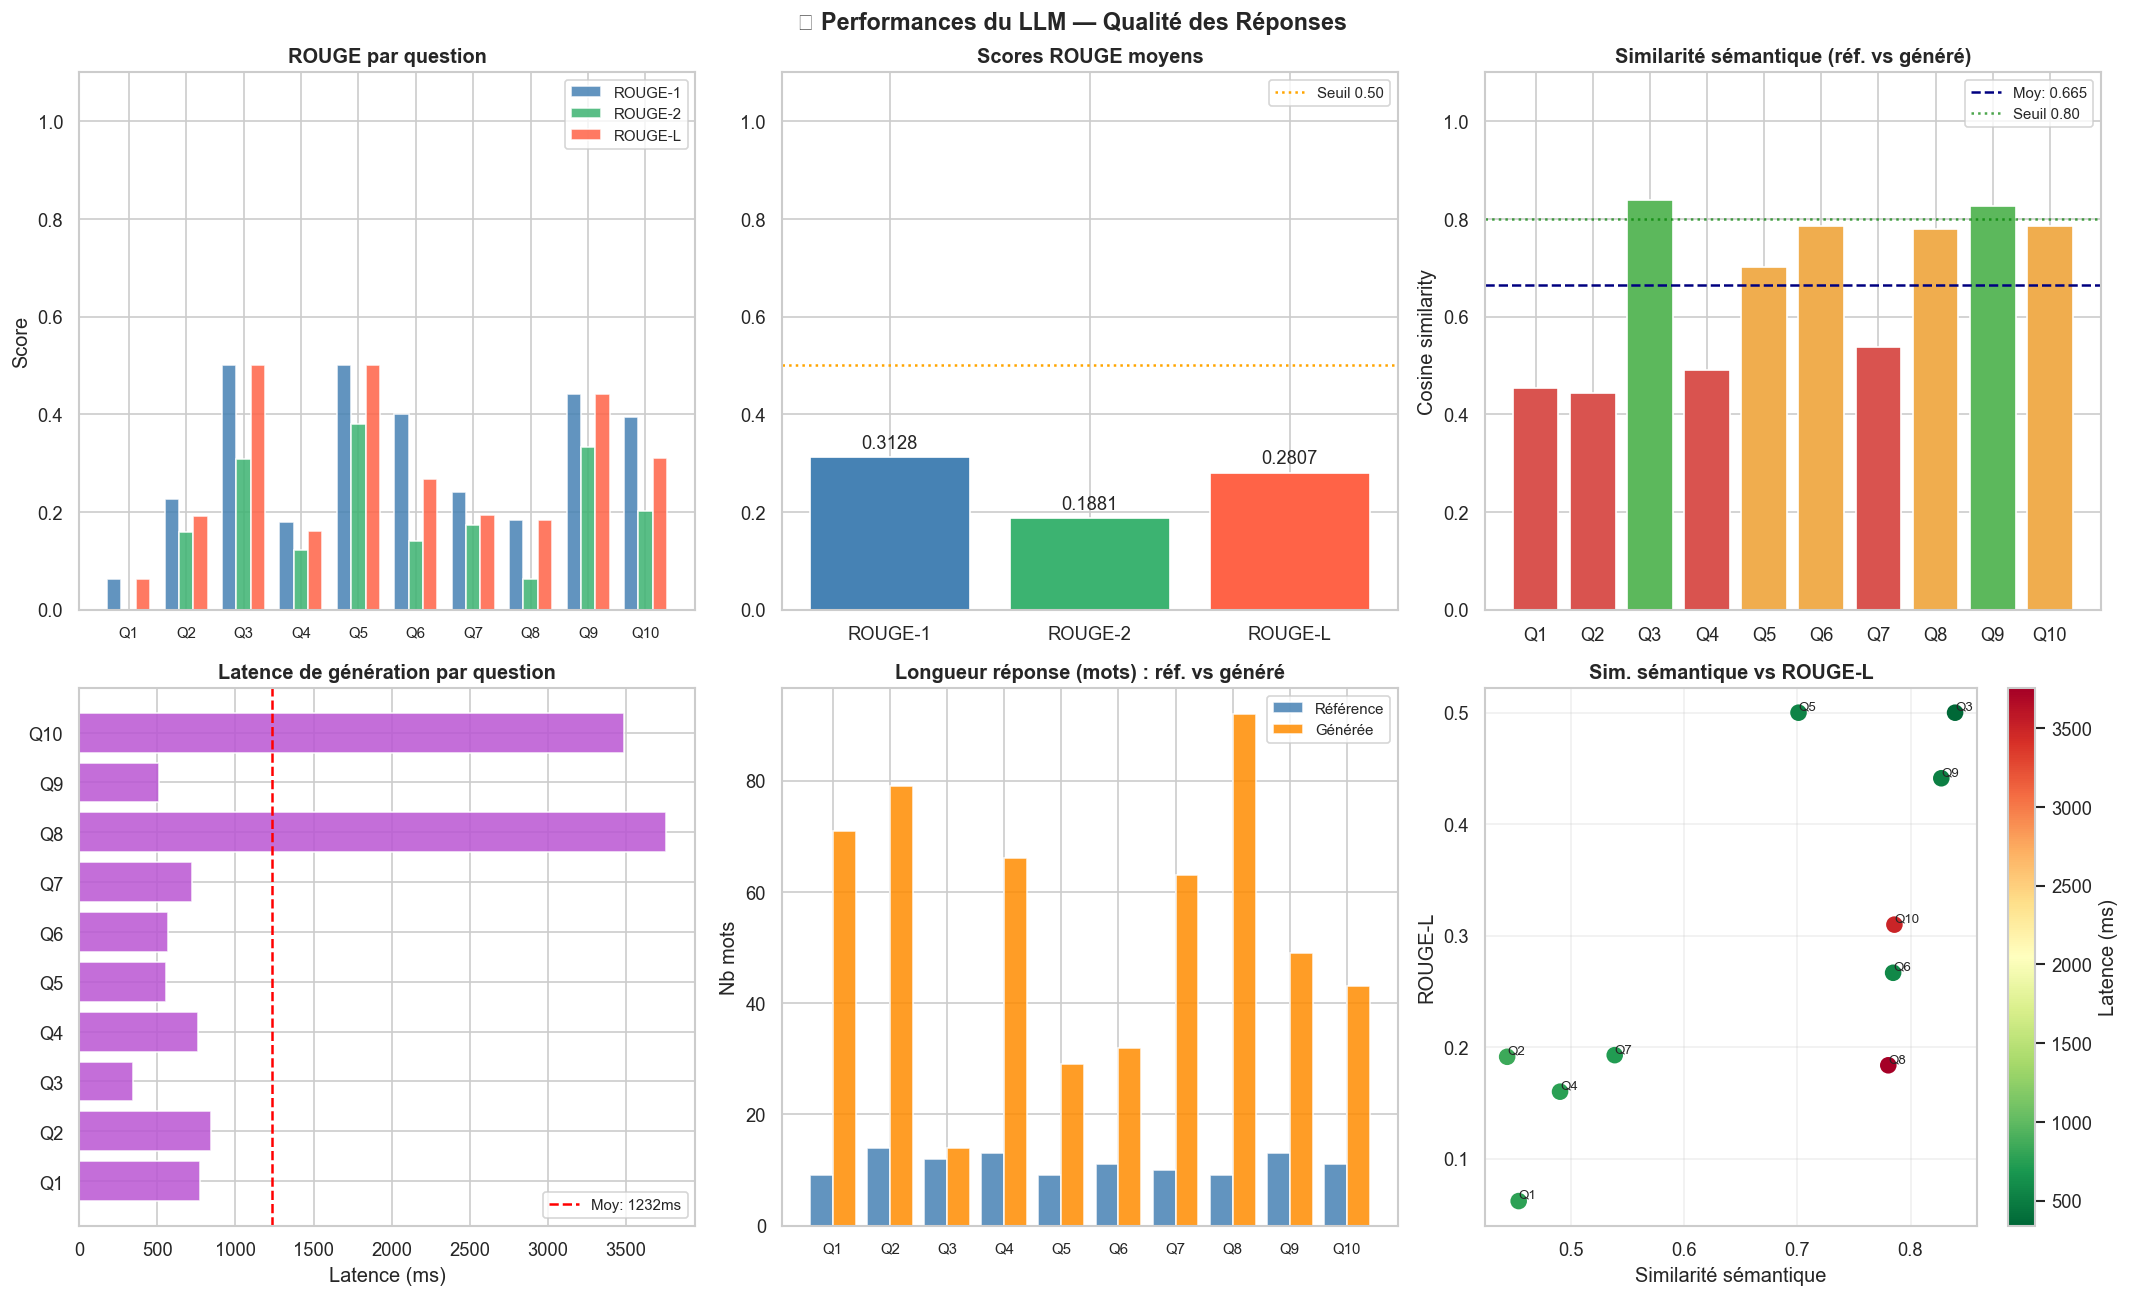

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('🤖 Performances du LLM — Qualité des Réponses', fontsize=14, fontweight='bold')

questions_short = [q[:35]+'…' for q in df_llm['question']]

# 1) ROUGE par question
ax = axes[0, 0]
if rouge_available:
    x = np.arange(len(df_llm))
    w = 0.25
    ax.bar(x - w, df_llm['ROUGE-1'], w, label='ROUGE-1', color='steelblue',      alpha=0.85)
    ax.bar(x,     df_llm['ROUGE-2'], w, label='ROUGE-2', color='mediumseagreen', alpha=0.85)
    ax.bar(x + w, df_llm['ROUGE-L'], w, label='ROUGE-L', color='tomato',         alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Q{i+1}' for i in range(len(df_llm))], fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_title('ROUGE par question', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylabel('Score')
else:
    ax.text(0.5, 0.5, 'pip install rouge-score', ha='center', va='center', transform=ax.transAxes)

# 2) Moyennes ROUGE
ax = axes[0, 1]
if rouge_available:
    rouge_means = [np.mean(r1_list), np.mean(r2_list), np.mean(rl_list)]
    bars = ax.bar(['ROUGE-1','ROUGE-2','ROUGE-L'], rouge_means,
                  color=['steelblue','mediumseagreen','tomato'], edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3)
    ax.set_ylim(0, 1.1)
    ax.set_title('Scores ROUGE moyens', fontweight='bold')
    ax.axhline(0.5, color='orange', linestyle=':', label='Seuil 0.50')
    ax.legend(fontsize=9)

# 3) Similarité sémantique
ax = axes[0, 2]
colors_sem = ['#5cb85c' if s >= 0.8 else '#f0ad4e' if s >= 0.6 else '#d9534f'
              for s in df_llm['sem_similarity']]
bars = ax.bar([f'Q{i+1}' for i in range(len(df_llm))],
              df_llm['sem_similarity'], color=colors_sem, edgecolor='white')
ax.axhline(df_llm['sem_similarity'].mean(), color='navy', linestyle='--',
           label=f'Moy: {df_llm["sem_similarity"].mean():.3f}')
ax.axhline(0.8, color='green', linestyle=':', alpha=0.7, label='Seuil 0.80')
ax.set_ylim(0, 1.1)
ax.set_title('Similarité sémantique (réf. vs généré)', fontweight='bold')
ax.set_ylabel('Cosine similarity')
ax.legend(fontsize=9)

# 4) Latence LLM
ax = axes[1, 0]
ax.barh([f'Q{i+1}' for i in range(len(df_llm))],
        df_llm['latency_ms'], color='mediumorchid', edgecolor='white', alpha=0.85)
ax.axvline(df_llm['latency_ms'].mean(), color='red', linestyle='--',
           label=f'Moy: {df_llm["latency_ms"].mean():.0f}ms')
ax.set_title('Latence de génération par question', fontweight='bold')
ax.set_xlabel('Latence (ms)')
ax.legend(fontsize=9)

# 5) Longueur réponse : référence vs généré
ax = axes[1, 1]
x = np.arange(len(df_llm))
ax.bar(x - 0.2, df_llm['ref_len'], 0.4, label='Référence', color='steelblue',   alpha=0.85)
ax.bar(x + 0.2, df_llm['gen_len'], 0.4, label='Générée',   color='darkorange',  alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Q{i+1}' for i in range(len(df_llm))], fontsize=9)
ax.set_title('Longueur réponse (mots) : réf. vs généré', fontweight='bold')
ax.set_ylabel('Nb mots')
ax.legend(fontsize=9)

# 6) Scatter : sim. sémantique vs ROUGE-L
ax = axes[1, 2]
if rouge_available:
    sc = ax.scatter(df_llm['sem_similarity'], df_llm['ROUGE-L'],
                    c=df_llm['latency_ms'], cmap='RdYlGn_r', s=80, zorder=3)
    plt.colorbar(sc, ax=ax, label='Latence (ms)')
    for i, row in df_llm.iterrows():
        ax.annotate(f'Q{i+1}', (row['sem_similarity'], row['ROUGE-L']),
                    fontsize=8, ha='left', va='bottom')
    ax.set_xlabel('Similarité sémantique')
    ax.set_ylabel('ROUGE-L')
    ax.set_title('Sim. sémantique vs ROUGE-L', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('llm_evaluation.png', bbox_inches='tight')
plt.show()

## ⚡ 7. Benchmark de vitesse — Pipeline complet end-to-end

In [36]:
benchmark_queries = [
    "Comment s'inscrire à la FSSM ?",
    "Quelles sont les filières de master disponibles ?",
    "Qu'est-ce que le CeDoc ?",
    "Comment valider un module à la FSSM ?",
    "Règles d'absences FSSM ?",
]

stage_results = []
N_RUNS = 5

for query in benchmark_queries:
    times_embed, times_retrieve, times_llm, times_total = [], [], [], []

    for _ in range(N_RUNS):
        # Étape 1 — Embedding
        t0 = time.perf_counter()
        q_vec = embed_model.encode_query(query)          # ✅ encode_query()
        t_embed = (time.perf_counter() - t0) * 1000

        # Étape 2 — Retrieval ChromaDB
        t0 = time.perf_counter()
        results_r = retriever.search(query, top_k=5)     # ✅ retriever.search()
        t_ret = (time.perf_counter() - t0) * 1000

        # Étape 3 — Génération LLM
        t0 = time.perf_counter()
        context = retriever.format_context(results_r)    # ✅ format_context()
        _ = generate_answer(query, context)
        t_llm = (time.perf_counter() - t0) * 1000

        times_embed.append(t_embed)
        times_retrieve.append(t_ret)
        times_llm.append(t_llm)
        times_total.append(t_embed + t_ret + t_llm)

    stage_results.append({
        'query'       : query[:45],
        'embed_ms'    : np.mean(times_embed),
        'retrieve_ms' : np.mean(times_retrieve),
        'llm_ms'      : np.mean(times_llm),
        'total_ms'    : np.mean(times_total),
        'total_ms_std': np.std(times_total),
    })
    print(f'  ✅ "{query[:40]}" — total: {np.mean(times_total):.0f}ms')

df_bench = pd.DataFrame(stage_results)
total_moy = df_bench['total_ms'].mean()
print(f'\n📊 Latence totale moy. : {total_moy:.0f} ms')
print(f'   Embed  : {df_bench["embed_ms"].mean():.1f} ms  ({df_bench["embed_ms"].mean()/total_moy*100:.0f}%)')
print(f'   Retrie.: {df_bench["retrieve_ms"].mean():.1f} ms  ({df_bench["retrieve_ms"].mean()/total_moy*100:.0f}%)')
print(f'   LLM    : {df_bench["llm_ms"].mean():.1f} ms  ({df_bench["llm_ms"].mean()/total_moy*100:.0f}%)')

  ✅ "Comment s'inscrire à la FSSM ?" — total: 997ms
  ✅ "Quelles sont les filières de master disp" — total: 770ms
  ✅ "Qu'est-ce que le CeDoc ?" — total: 1236ms
  ✅ "Comment valider un module à la FSSM ?" — total: 4629ms
  ✅ "Règles d'absences FSSM ?" — total: 5180ms

📊 Latence totale moy. : 2563 ms
   Embed  : 179.3 ms  (7%)
   Retrie.: 99.1 ms  (4%)
   LLM    : 2284.3 ms  (89%)


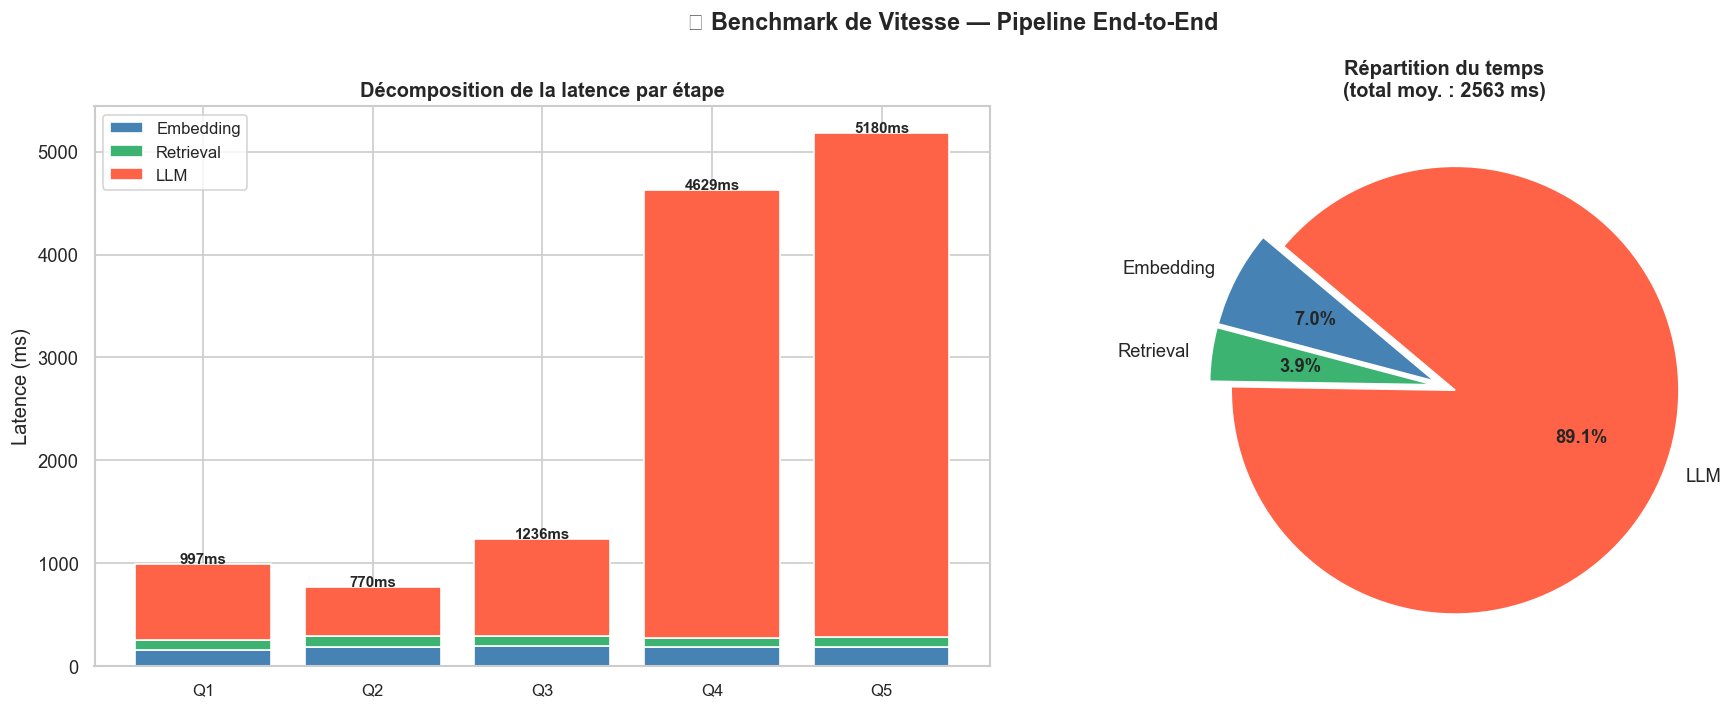

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('⚡ Benchmark de Vitesse — Pipeline End-to-End', fontsize=14, fontweight='bold')

# 1) Stacked bar par query
ax = axes[0]
x = np.arange(len(df_bench))
q_labels = [f'Q{i+1}' for i in range(len(df_bench))]
p1 = ax.bar(x, df_bench['embed_ms'],    label='Embedding',  color='steelblue',      edgecolor='white')
p2 = ax.bar(x, df_bench['retrieve_ms'], label='Retrieval',  color='mediumseagreen', edgecolor='white',
            bottom=df_bench['embed_ms'])
p3 = ax.bar(x, df_bench['llm_ms'],      label='LLM',        color='tomato',         edgecolor='white',
            bottom=df_bench['embed_ms'] + df_bench['retrieve_ms'])
ax.set_xticks(x)
ax.set_xticklabels(q_labels, fontsize=10)
ax.set_title('Décomposition de la latence par étape', fontweight='bold')
ax.set_ylabel('Latence (ms)')
ax.legend(fontsize=10)
for i, row in df_bench.iterrows():
    ax.text(i, row['total_ms']+5, f'{row["total_ms"]:.0f}ms', ha='center', fontsize=9, fontweight='bold')

# 2) Pie chart — part de chaque étape
ax = axes[1]
stage_means = [
    df_bench['embed_ms'].mean(),
    df_bench['retrieve_ms'].mean(),
    df_bench['llm_ms'].mean(),
]
labels_pie  = ['Embedding', 'Retrieval', 'LLM']
colors_pie  = ['steelblue', 'mediumseagreen', 'tomato']
explode     = [0.05, 0.05, 0.05]
wedges, texts, autotexts = ax.pie(
    stage_means, labels=labels_pie, autopct='%1.1f%%',
    colors=colors_pie, startangle=140, explode=explode,
    textprops={'fontsize':11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title(f'Répartition du temps\n(total moy. : {sum(stage_means):.0f} ms)', fontweight='bold')

plt.tight_layout()
plt.savefig('pipeline_benchmark.png', bbox_inches='tight')
plt.show()

## 🔬 8. Analyse des cas d'échec du retrieval

In [38]:
# Cas où le rang > 5 (retrieval raté)
failures = df_per_query[df_per_query['rank'] > 5].sort_values('rank', ascending=False)

print(f'\n❌ Cas d\'échec retrieval (rang > 5) : {len(failures)} / {len(df_per_query)}')
print(f'   Taux d\'échec : {len(failures)/len(df_per_query)*100:.1f}%\n')

if not failures.empty:
    print('🔍 Top 10 cas les plus problématiques :')
    display(failures[['query','category','rank','mrr','ndcg@10']].head(10).to_string(index=False))

    # Répartition des échecs par catégorie
    print('\n📊 Échecs par catégorie :')
    fail_by_cat = failures['category'].value_counts()
    total_by_cat = df_per_query['category'].value_counts()
    for cat in fail_by_cat.index:
        rate = fail_by_cat[cat] / total_by_cat.get(cat, 1) * 100
        print(f'   {cat:15s} : {fail_by_cat[cat]} échecs / {total_by_cat.get(cat,0)} ({rate:.1f}%)')


❌ Cas d'échec retrieval (rang > 5) : 62 / 200
   Taux d'échec : 31.0%

🔍 Top 10 cas les plus problématiques :


"                                                       query      category  rank  mrr  ndcg@10\n                       Critères d'admission FSSM Marrakech ? administratif   162  0.0      0.0\n                                            FSSM accès PMR ?    université   121  0.0      0.0\n                                     Mentions licence FSSM ?     pédagogie   117  0.0      0.0\n                                      Département SVT FSSM ?    université    91  0.0      0.0\n                                Aide financière thèse FSSM ?     formation    85  0.0      0.0\nY a-t-il un rattrapage pour les projets de fin d'études à la     pédagogie    82  0.0      0.0\n                           Restauration universitaire FSSM ? administratif    64  0.0      0.0\n                     Formation transversale doctorant FSSM ?     formation    56  0.0      0.0\n                            Contenu examen rattrapage FSSM ?     pédagogie    55  0.0      0.0\n                                 Master


📊 Échecs par catégorie :
   université      : 20 échecs / 56 (35.7%)
   pédagogie       : 20 échecs / 66 (30.3%)
   administratif   : 13 échecs / 40 (32.5%)
   formation       : 9 échecs / 38 (23.7%)


## 📋 9. Rapport de performance final — Résumé exécutif

In [39]:
def rating(val, seuils):
    """(val, [(seuil, emoji), ...]) → emoji"""
    for seuil, emoji in seuils:
        if val >= seuil:
            return emoji
    return '🔴'

print('\n' + '='*58)
print('       📋 RAPPORT DE PERFORMANCE — PIPELINE RAG FSSM')
print('='*58)

print('\n  🧲 EMBEDDING MODEL')
print(f'     Dimension vecteur     : {embeddings.shape[1]}')
print(f'     Norme moy.            : {norms.mean():.4f}')
print(f'     Séparation intra/inter: {sep:.4f}   {rating(sep, [(0.1,"🟢"),(0.05,"🟡"),(0,"🔴")])}')
print(f'     Latence encodage      : {np.mean(times_single):.1f} ms')

print('\n  🔍 RETRIEVAL (FAISS)')
for k in [1, 3, 5, 10]:
    v = metrics[f'Hit@{k}']
    grade = rating(v, [(0.9,'🟢'),(0.75,'🟡'),(0,'🔴')])
    print(f'     Hit@{k:<3}              : {v:.4f}   {grade}')
print(f'     MRR                   : {metrics["MRR"]:.4f}   {rating(metrics["MRR"],[(0.85,"🟢"),(0.7,"🟡"),(0,"🔴")])}')
print(f'     NDCG@10               : {metrics["NDCG@10"]:.4f}   {rating(metrics["NDCG@10"],[(0.85,"🟢"),(0.7,"🟡"),(0,"🔴")])}')
print(f'     Latence moy.          : {metrics["Latence moy (ms)"]:.2f} ms')
print(f'     Latence p95           : {metrics["Latence p95 (ms)"]:.2f} ms')

print('\n  🤖 LLM (Génération)')
if rouge_available:
    print(f'     ROUGE-1               : {np.mean(r1_list):.4f}   {rating(np.mean(r1_list),[(0.6,"🟢"),(0.4,"🟡"),(0,"🔴")])}')
    print(f'     ROUGE-2               : {np.mean(r2_list):.4f}   {rating(np.mean(r2_list),[(0.4,"🟢"),(0.25,"🟡"),(0,"🔴")])}')
    print(f'     ROUGE-L               : {np.mean(rl_list):.4f}   {rating(np.mean(rl_list),[(0.5,"🟢"),(0.35,"🟡"),(0,"🔴")])}')
sem_mean = df_llm['sem_similarity'].mean()
print(f'     Sim. sémantique moy.  : {sem_mean:.4f}   {rating(sem_mean,[(0.8,"🟢"),(0.65,"🟡"),(0,"🔴")])}')
print(f'     Latence génération    : {df_llm["latency_ms"].mean():.0f} ms')

print('\n  ⚡ PIPELINE END-TO-END')
total_moy = df_bench['total_ms'].mean()
print(f'     Latence totale moy.   : {total_moy:.0f} ms   {rating(1/total_moy,[(1/2000,"🟢"),(1/5000,"🟡"),(0,"🔴")])}')
print(f'     Embed  (part)         : {df_bench["embed_ms"].mean():.1f} ms  ({df_bench["embed_ms"].mean()/total_moy*100:.0f}%)')
print(f'     Retriev.(part)        : {df_bench["retrieve_ms"].mean():.1f} ms  ({df_bench["retrieve_ms"].mean()/total_moy*100:.0f}%)')
print(f'     LLM    (part)         : {df_bench["llm_ms"].mean():.1f} ms  ({df_bench["llm_ms"].mean()/total_moy*100:.0f}%)')
print('\n  LÉGENDE : 🟢 Excellent  🟡 Acceptable  🔴 À améliorer')
print('='*58)
print('  Graphiques sauvegardés :')
for f in ['embeddings_analysis.png','embeddings_2d.png',
          'retrieval_metrics.png','llm_evaluation.png','pipeline_benchmark.png']:
    print(f'    → {f}')
print('='*58)


       📋 RAPPORT DE PERFORMANCE — PIPELINE RAG FSSM

  🧲 EMBEDDING MODEL
     Dimension vecteur     : 768
     Norme moy.            : 2.5292
     Séparation intra/inter: 0.0849   🟡
     Latence encodage      : 88.2 ms

  🔍 RETRIEVAL (FAISS)
     Hit@1                : 0.3950   🔴
     Hit@3                : 0.6450   🔴
     Hit@5                : 0.6900   🔴
     Hit@10               : 0.7700   🟡
     MRR                   : 0.5248   🔴
     NDCG@10               : 0.5843   🔴
     Latence moy.          : 82.43 ms
     Latence p95           : 108.31 ms

  🤖 LLM (Génération)
     ROUGE-1               : 0.3128   🔴
     ROUGE-2               : 0.1881   🔴
     ROUGE-L               : 0.2807   🔴
     Sim. sémantique moy.  : 0.6645   🟡
     Latence génération    : 1232 ms

  ⚡ PIPELINE END-TO-END
     Latence totale moy.   : 2563 ms   🟡
     Embed  (part)         : 179.3 ms  (7%)
     Retriev.(part)        : 99.1 ms  (4%)
     LLM    (part)         : 2284.3 ms  (89%)

  LÉGENDE : 🟢 Excellent  

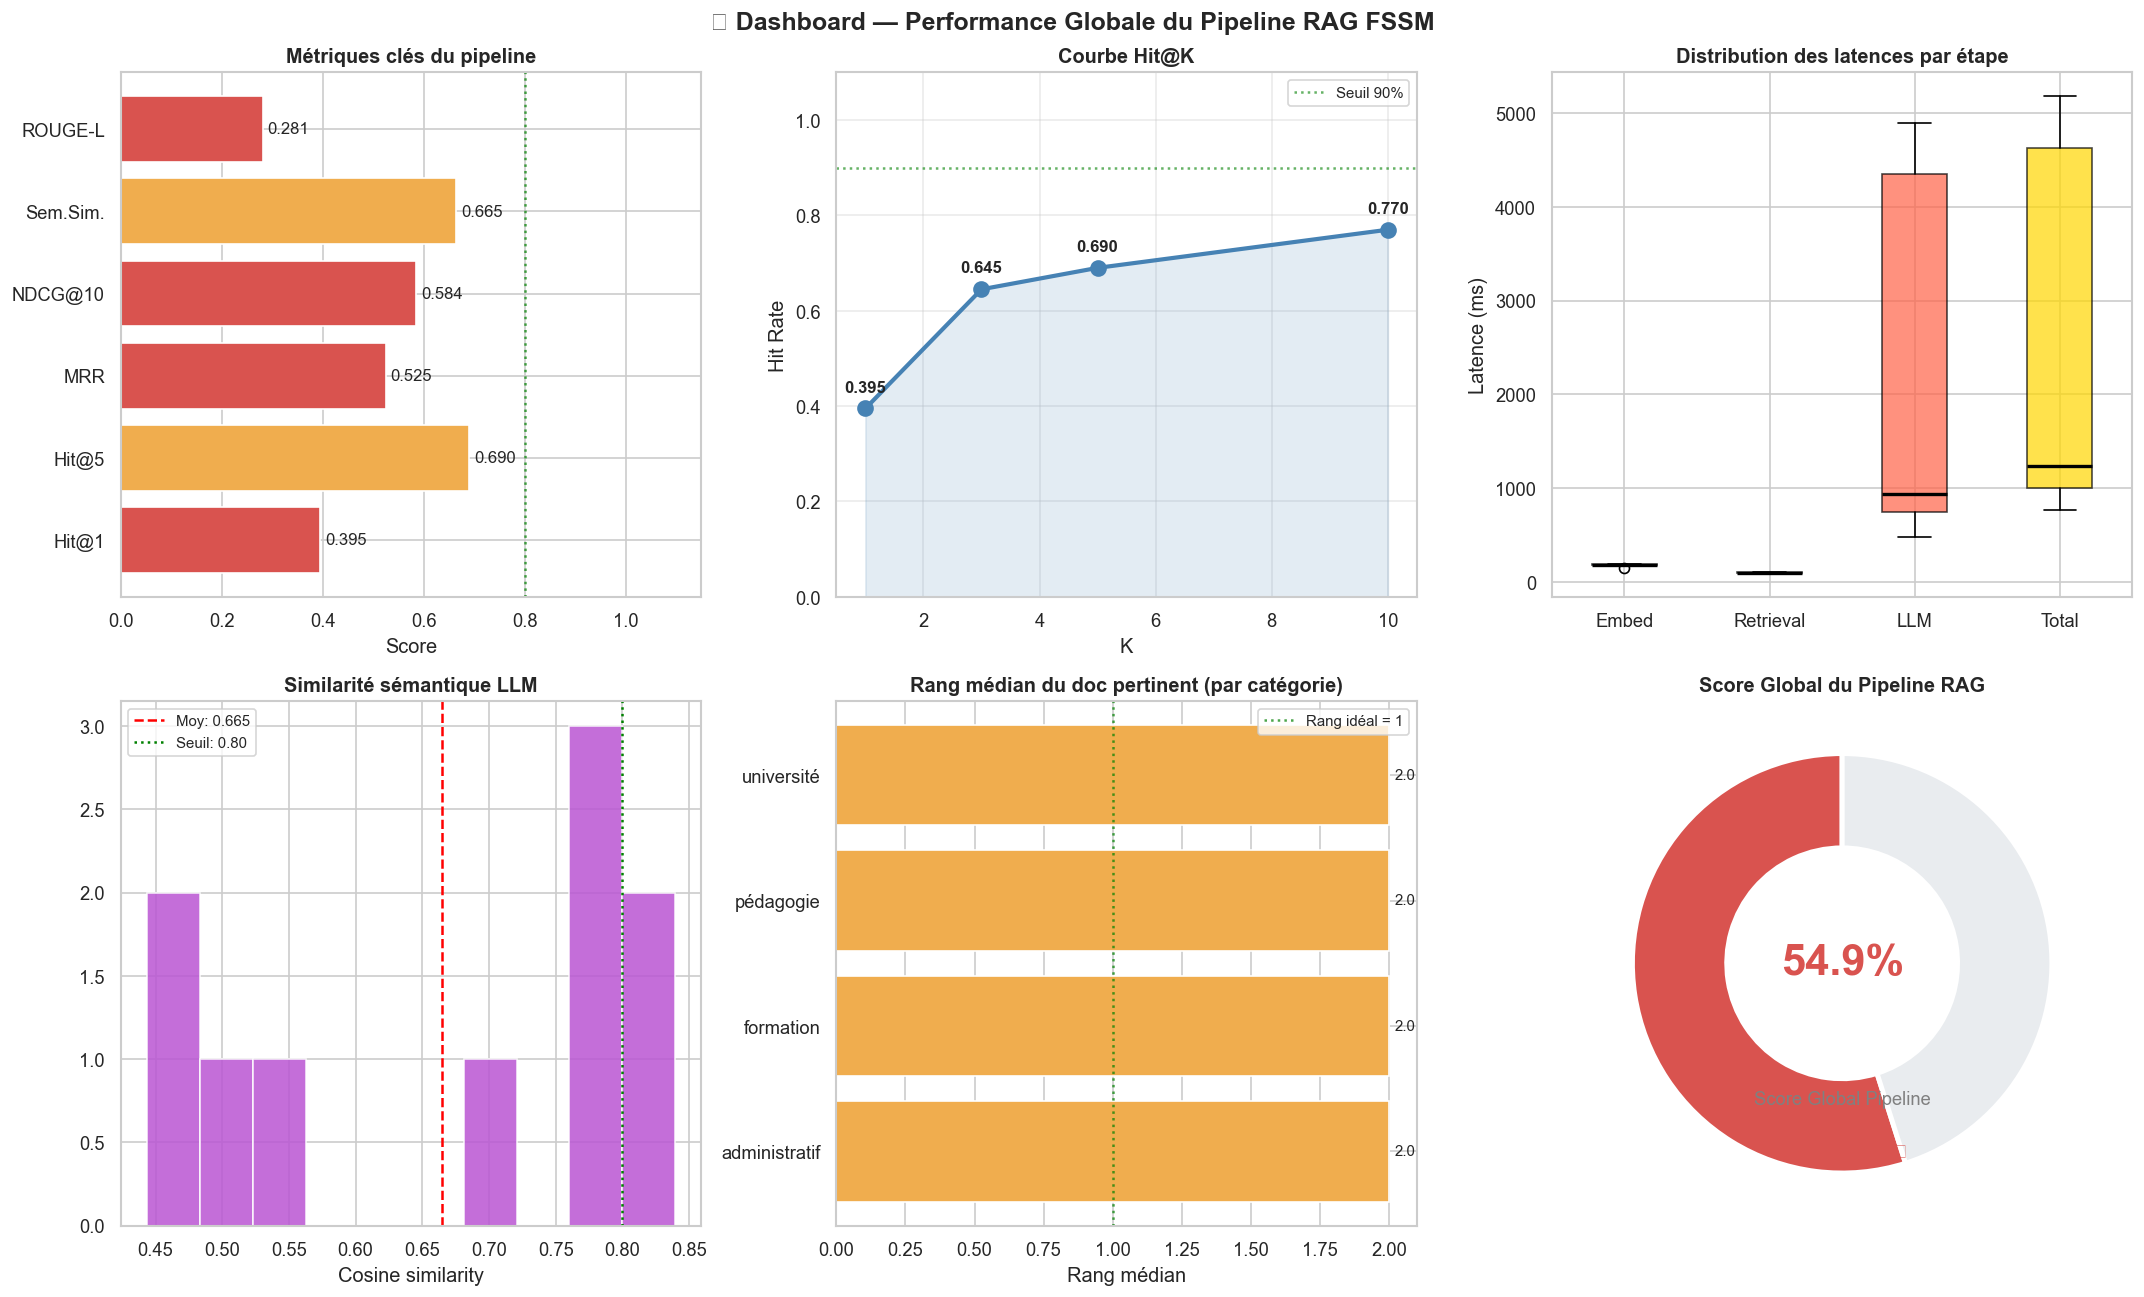


✅ Dashboard sauvegardé : global_dashboard.png
🎯 Score global du pipeline : 54.9%  →  À améliorer ❌


In [40]:
# ── Dashboard récapitulatif ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('🎯 Dashboard — Performance Globale du Pipeline RAG FSSM',
             fontsize=15, fontweight='bold')

# 1) Radar chart — métriques clés
ax = axes[0, 0]
radar_metrics = {
    'Hit@1'     : metrics['Hit@1'],
    'Hit@5'     : metrics['Hit@5'],
    'MRR'       : metrics['MRR'],
    'NDCG@10'   : metrics['NDCG@10'],
    'Sem.Sim.'  : df_llm['sem_similarity'].mean(),
    'ROUGE-L'   : np.mean(rl_list) if rouge_available else 0,
}
names  = list(radar_metrics.keys())
values = list(radar_metrics.values())
colors_r = ['#5cb85c' if v >= 0.8 else '#f0ad4e' if v >= 0.6 else '#d9534f' for v in values]
bars = ax.barh(names, values, color=colors_r, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax.axvline(0.8, color='green', linestyle=':', alpha=0.7)
ax.set_xlim(0, 1.15)
ax.set_title('Métriques clés du pipeline', fontweight='bold')
ax.set_xlabel('Score')

# 2) Evolution Hit@K
ax = axes[0, 1]
k_vals  = [1, 3, 5, 10]
hit_vals = [metrics[f'Hit@{k}'] for k in k_vals]
ax.plot(k_vals, hit_vals, 'o-', color='steelblue', linewidth=2.5, markersize=9)
for k, v in zip(k_vals, hit_vals):
    ax.annotate(f'{v:.3f}', (k, v), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
ax.fill_between(k_vals, hit_vals, alpha=0.15, color='steelblue')
ax.set_xlim(0.5, 10.5)
ax.set_ylim(0, 1.1)
ax.set_title('Courbe Hit@K', fontweight='bold')
ax.set_xlabel('K')
ax.set_ylabel('Hit Rate')
ax.axhline(0.9, color='green', linestyle=':', alpha=0.6, label='Seuil 90%')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# 3) Latences par étape (boxplot)
ax = axes[0, 2]
bp_data  = [df_bench['embed_ms'], df_bench['retrieve_ms'], df_bench['llm_ms'], df_bench['total_ms']]
bp_labels = ['Embed', 'Retrieval', 'LLM', 'Total']
bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True,
                medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], ['steelblue','mediumseagreen','tomato','gold']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Distribution des latences par étape', fontweight='bold')
ax.set_ylabel('Latence (ms)')

# 4) Similarité sémantique (distribution)
ax = axes[1, 0]
ax.hist(df_llm['sem_similarity'], bins=10, color='mediumorchid',
        edgecolor='white', alpha=0.85)
ax.axvline(df_llm['sem_similarity'].mean(), color='red', linestyle='--',
           label=f'Moy: {df_llm["sem_similarity"].mean():.3f}')
ax.axvline(0.8, color='green', linestyle=':', label='Seuil: 0.80')
ax.set_title('Similarité sémantique LLM', fontweight='bold')
ax.set_xlabel('Cosine similarity')
ax.legend(fontsize=9)

# 5) Rang médian par catégorie
ax = axes[1, 1]
rank_by_cat = df_per_query.groupby('category')['rank'].median().sort_values()
colors_rc = ['#5cb85c' if v <= 1 else '#f0ad4e' if v <= 3 else '#d9534f' for v in rank_by_cat]
bars = ax.barh(rank_by_cat.index, rank_by_cat.values, color=colors_rc, edgecolor='white')
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.axvline(1, color='green', linestyle=':', alpha=0.7, label='Rang idéal = 1')
ax.set_title('Rang médian du doc pertinent (par catégorie)', fontweight='bold')
ax.set_xlabel('Rang médian')
ax.legend(fontsize=9)

# 6) Score global synthèse
ax = axes[1, 2]
global_score = np.mean([
    metrics['Hit@5'],
    metrics['MRR'],
    metrics['NDCG@10'],
    df_llm['sem_similarity'].mean(),
    (np.mean(rl_list) if rouge_available else 0.5),
]) * 100

color_gs = '#5cb85c' if global_score >= 80 else '#f0ad4e' if global_score >= 65 else '#d9534f'
wedge_vals = [global_score, 100 - global_score]
wedge_cols = [color_gs, '#e9ecef']
ax.pie(wedge_vals, startangle=90, colors=wedge_cols,
       wedgeprops={'width': 0.45, 'edgecolor':'white', 'linewidth':3})
ax.text(0, 0, f'{global_score:.1f}%', ha='center', va='center',
        fontsize=26, fontweight='bold', color=color_gs)
ax.text(0, -0.65, 'Score Global Pipeline', ha='center', va='center',
        fontsize=11, color='gray')
verdict = 'Excellent ✅' if global_score >= 80 else 'Acceptable ⚠️' if global_score >= 65 else 'À améliorer ❌'
ax.text(0, -0.9, verdict, ha='center', va='center', fontsize=12, fontweight='bold', color=color_gs)
ax.set_title('Score Global du Pipeline RAG', fontweight='bold')

plt.tight_layout()
plt.savefig('global_dashboard.png', bbox_inches='tight')
plt.show()
print(f'\n✅ Dashboard sauvegardé : global_dashboard.png')
print(f'🎯 Score global du pipeline : {global_score:.1f}%  →  {verdict}')